# FESOMP Mesh Module Tutorial

This notebook demonstrates how to work with FESOM2 unstructured mesh data using the `fesomp` package.

## 1. Loading a Mesh

The `load_mesh` function automatically detects the format based on the path:
- `.nc` file → NetCDF format (with pre-computed topology/geometry)
- Directory → ASCII format (topology/geometry computed on demand)

In [1]:
from fesomp import load_mesh

# Load from NetCDF (recommended - faster, includes pre-computed values)
mesh = load_mesh("../tests/data/pi-mesh/fesom.mesh.diag.nc")

# Or load from ASCII files directory
# mesh = load_mesh("../tests/data/pi-mesh/")

print(mesh)

Mesh(n2d=3140, nelem=5839, nlev=48, lon=[-179.96, 179.96], lat=[-78.52, 89.40])


## 2. Basic Mesh Properties

The mesh object provides access to fundamental properties of the unstructured grid.

In [2]:
# Number of nodes (vertices) in the 2D mesh
print(f"Number of nodes (n2d): {mesh.n2d}")

# Number of triangular elements
print(f"Number of elements (nelem): {mesh.nelem}")

# Number of vertical levels
print(f"Number of vertical levels (nlev): {mesh.nlev}")

Number of nodes (n2d): 3140
Number of elements (nelem): 5839
Number of vertical levels (nlev): 48


In [3]:
# Node coordinates
print(f"Longitude range: {mesh.lon.min():.2f}° to {mesh.lon.max():.2f}°")
print(f"Latitude range: {mesh.lat.min():.2f}° to {mesh.lat.max():.2f}°")

# First 5 node coordinates
print("\nFirst 5 nodes (lon, lat):")
for i in range(5):
    print(f"  Node {i}: ({mesh.lon[i]:.4f}, {mesh.lat[i]:.4f})")

Longitude range: -179.96° to 179.96°
Latitude range: -78.52° to 89.40°

First 5 nodes (lon, lat):
  Node 0: (-60.6012, 74.2829)
  Node 1: (-60.7301, 73.9118)
  Node 2: (-62.1527, 74.0515)
  Node 3: (-60.7111, 74.6291)
  Node 4: (-62.0336, 74.4895)


In [4]:
# Triangle connectivity (0-indexed)
# Each row contains indices of the 3 vertices forming a triangle
print(f"Triangles shape: {mesh.triangles.shape}")
print(f"\nFirst 5 triangles (node indices):")
for i in range(5):
    tri = mesh.triangles[i]
    print(f"  Element {i}: nodes {tri}")

Triangles shape: (5839, 3)

First 5 triangles (node indices):
  Element 0: nodes [ 0 11  1]
  Element 1: nodes [ 1 11  9]
  Element 2: nodes [1 9 8]
  Element 3: nodes [2 0 1]
  Element 4: nodes [2 4 0]


## 3. Vertical Structure

FESOM2 uses a hybrid vertical coordinate system. Each node can have a different number of active levels depending on bathymetry.

In [5]:
# Depth levels (interfaces between layers)
print(f"Depth levels (first 10): {mesh.depth_levels[:10]}")
print(f"Maximum depth: {mesh.depth_levels.max():.1f} m")

# Depth layers (centers of layers)
print(f"\nDepth layers (first 10): {mesh.depth_layers[:10]}")

Depth levels (first 10): [-0.  5. 10. 20. 30. 40. 50. 60. 70. 80.]
Maximum depth: 6250.0 m

Depth layers (first 10): [ 2.5  7.5 15.  25.  35.  45.  55.  65.  75.  85. ]


In [6]:
# Number of active levels varies by location (bathymetry)
print(f"Node levels range: {mesh.node_levels.min()} to {mesh.node_levels.max()}")
print(f"Element levels range: {mesh.elem_levels.min()} to {mesh.elem_levels.max()}")

# Bottom depth at nodes
print(f"\nBottom depth range: {mesh.node_bottom_depth.min():.1f} to {mesh.node_bottom_depth.max():.1f} m")

Node levels range: 5 to 46
Element levels range: 5 to 46

Bottom depth range: 30.0 to 5650.0 m


In [7]:
import numpy as np

# Distribution of node levels (how deep the water column is at each node)
unique_levels, counts = np.unique(mesh.node_levels, return_counts=True)
print("Distribution of node levels:")
for level, count in zip(unique_levels[::5], counts[::5]):  # Every 5th for brevity
    print(f"  {level} levels: {count} nodes")

Distribution of node levels:
  5 levels: 12 nodes
  10 levels: 15 nodes
  15 levels: 25 nodes
  20 levels: 51 nodes
  25 levels: 52 nodes
  30 levels: 72 nodes
  35 levels: 110 nodes
  40 levels: 172 nodes
  45 levels: 88 nodes


## 4. Mesh Topology

Topology describes the connectivity relationships between mesh elements. It is computed lazily on first access.

In [8]:
# Access topology (computed/loaded on first access)
topo = mesh.topology

print(f"Number of edges: {topo.nedges}")
print(f"Edges shape: {topo.edges.shape}")
print(f"\nFirst 5 edges (node pairs):")
for i in range(5):
    print(f"  Edge {i}: nodes {topo.edges[i]}")

Number of edges: 8986
Edges shape: (8986, 2)

First 5 edges (node pairs):
  Edge 0: nodes [ 0 11]
  Edge 1: nodes [0 1]
  Edge 2: nodes [0 2]
  Edge 3: nodes [0 4]
  Edge 4: nodes [0 3]


In [9]:
# Face neighbors - which elements share edges
# -1 indicates a boundary (no neighbor)
print("Face neighbors for first 5 elements:")
print("(Each element has 3 neighbors, -1 = boundary)")
for i in range(5):
    neighbors = topo.face_neighbors[i]
    print(f"  Element {i}: neighbors {neighbors}")

Face neighbors for first 5 elements:
(Each element has 3 neighbors, -1 = boundary)
  Element 0: neighbors [ 1  3 22]
  Element 1: neighbors [23  2  0]
  Element 2: neighbors [16 17  1]
  Element 3: neighbors [ 0 17  4]
  Element 4: neighbors [ 7  3 24]


In [10]:
# Find boundary edges and nodes
boundary_edges = topo.get_boundary_edges()
boundary_nodes = topo.get_boundary_nodes()

print(f"Number of boundary edges: {len(boundary_edges)}")
print(f"Number of boundary nodes: {len(boundary_nodes)}")
print(f"Boundary node percentage: {100 * len(boundary_nodes) / mesh.n2d:.1f}%")

Number of boundary edges: 455
Number of boundary nodes: 455
Boundary node percentage: 14.5%


In [11]:
# Node-to-elements mapping: which elements contain each node
node_idx = 100
elements_containing_node = topo.node_elements[node_idx]
print(f"Node {node_idx} is part of {len(elements_containing_node)} elements: {elements_containing_node}")

Node 100 is part of 4 elements: [125 126 185 256]


## 5. Mesh Geometry

Geometry provides area calculations using spherical formulas (accounting for Earth's curvature).

In [12]:
# Access geometry (computed/loaded on first access)
geom = mesh.geometry

# Element areas in m²
print(f"Element areas shape: {geom.elem_area.shape}")
print(f"Element area range: {geom.elem_area.min():.2e} to {geom.elem_area.max():.2e} m²")

# Convert to km² for readability
area_km2 = geom.elem_area / 1e6
print(f"Element area range: {area_km2.min():.1f} to {area_km2.max():.1f} km²")
print(f"Total mesh area: {area_km2.sum():.2e} km²")

Element areas shape: (5839,)
Element area range: 6.62e+08 to 5.28e+11 m²
Element area range: 662.2 to 528340.0 km²
Total mesh area: 3.40e+08 km²


In [13]:
# Node areas (area associated with each node at each level)
# Used for volume-weighted calculations
print(f"Node area shape: {geom.node_area.shape}  (nlev x n2d)")

# Surface node area (level 0)
surface_node_area = geom.node_area[0, :]
print(f"Surface node area range: {surface_node_area.min()/1e6:.1f} to {surface_node_area.max()/1e6:.1f} km²")

Node area shape: (48, 3140)  (nlev x n2d)
Surface node area range: 1262.3 to 1118376.7 km²


## 6. Spatial Queries

The mesh provides efficient spatial queries using a KD-tree built on 3D Cartesian coordinates (for accurate spherical distance).

In [14]:
# Find the nearest node to a point
query_lon, query_lat = -45.0, 60.0

nearest_idx = mesh.find_nearest(query_lon, query_lat, k=1)
print(f"Query point: ({query_lon}, {query_lat})")
print(f"Nearest node index: {nearest_idx}")
print(f"Nearest node coordinates: ({mesh.lon[nearest_idx]:.4f}, {mesh.lat[nearest_idx]:.4f})")

Query point: (-45.0, 60.0)
Nearest node index: 763
Nearest node coordinates: (-45.8812, 60.4866)


In [15]:
# Find k nearest neighbors
k = 5
nearest_k = mesh.find_nearest(query_lon, query_lat, k=k)

print(f"{k} nearest nodes to ({query_lon}, {query_lat}):")
for i, idx in enumerate(nearest_k):
    print(f"  {i+1}. Node {idx}: ({mesh.lon[idx]:.4f}, {mesh.lat[idx]:.4f})")

5 nearest nodes to (-45.0, 60.0):
  1. Node 763: (-45.8812, 60.4866)
  2. Node 816: (-43.6869, 59.6810)
  3. Node 815: (-45.6070, 59.1757)
  4. Node 814: (-47.4843, 59.2028)
  5. Node 764: (-42.6666, 60.9654)


In [16]:
# Find all nodes within a radius (in kilometers)
radius_km = 500  # 500 km radius

nodes_in_radius = mesh.find_in_radius(query_lon, query_lat, radius_km=radius_km)
print(f"Nodes within {radius_km} km of ({query_lon}, {query_lat}): {len(nodes_in_radius)} nodes")
print(f"Node indices: {nodes_in_radius[:10]}..." if len(nodes_in_radius) > 10 else f"Node indices: {nodes_in_radius}")

Nodes within 500 km of (-45.0, 60.0): 38 nodes
Node indices: [708 711 762 751 655 709 765 814 763 818]...


In [17]:
# Find nodes within a bounding box
lon_min, lon_max = -50, -40
lat_min, lat_max = 55, 65

nodes_in_bbox = mesh.subset_by_bbox(lon_min, lon_max, lat_min, lat_max)
print(f"Nodes in bbox [{lon_min}, {lon_max}] x [{lat_min}, {lat_max}]: {len(nodes_in_bbox)} nodes")

Nodes in bbox [-50, -40] x [55, 65]: 24 nodes


## 7. Visualization

Basic visualization of the mesh using matplotlib.

**Important**: Global unstructured meshes often have triangles that cross the dateline (±180°). 
These triangles would cause matplotlib to draw lines spanning the entire globe. 
We create a mask to exclude such triangles from visualization.

In [18]:
import matplotlib.pyplot as plt
import matplotlib.tri as mtri

# Create a triangulation object for plotting
# The get_triangulation() method automatically masks triangles crossing the dateline
triangulation = mesh.get_triangulation(mask_cyclic=True)

# You can also create it manually if needed:
# triangulation = mtri.Triangulation(mesh.lon, mesh.lat, mesh.triangles)
# tri_lon = mesh.lon[mesh.triangles]
# lon_range = tri_lon.max(axis=1) - tri_lon.min(axis=1)
# cyclic_mask = lon_range > 180
# triangulation.set_mask(cyclic_mask)

# Check how many triangles were masked
mask = triangulation.get_masked_triangles()
print(f"Total triangles: {mesh.nelem}")
print(f"Triangles for plotting (after masking dateline crossings): {len(mask)}")

Total triangles: 5839
Triangles for plotting (after masking dateline crossings): 5728


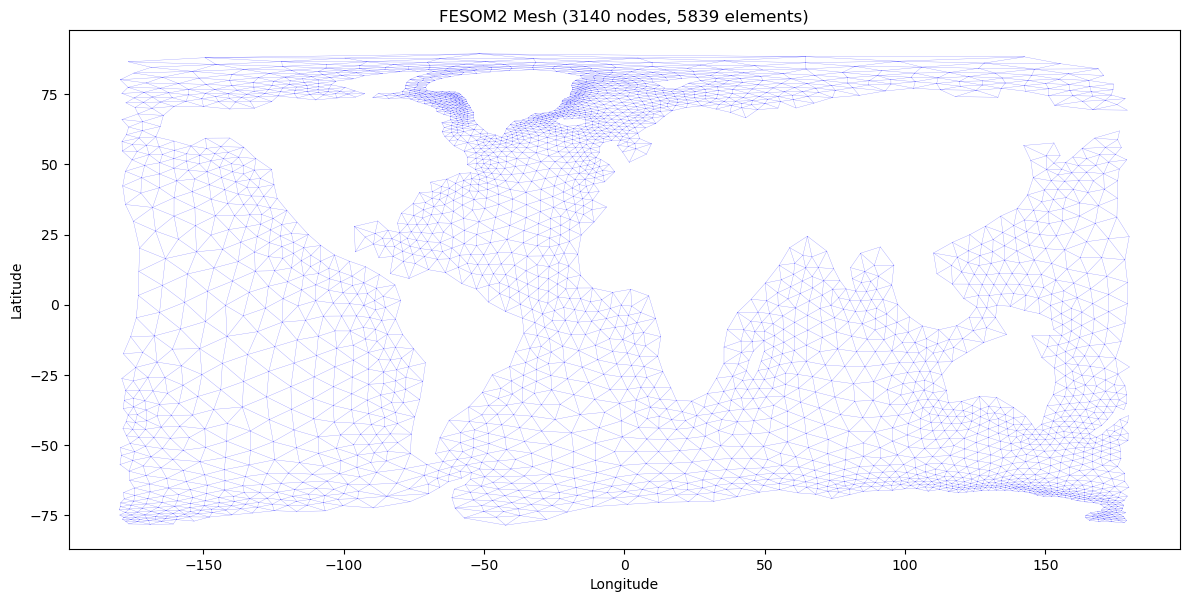

In [19]:
# Plot the mesh
fig, ax = plt.subplots(figsize=(12, 8))
ax.triplot(triangulation, 'b-', linewidth=0.2, alpha=0.5)
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_title(f'FESOM2 Mesh ({mesh.n2d} nodes, {mesh.nelem} elements)')
ax.set_aspect('equal')
plt.tight_layout()
plt.show()

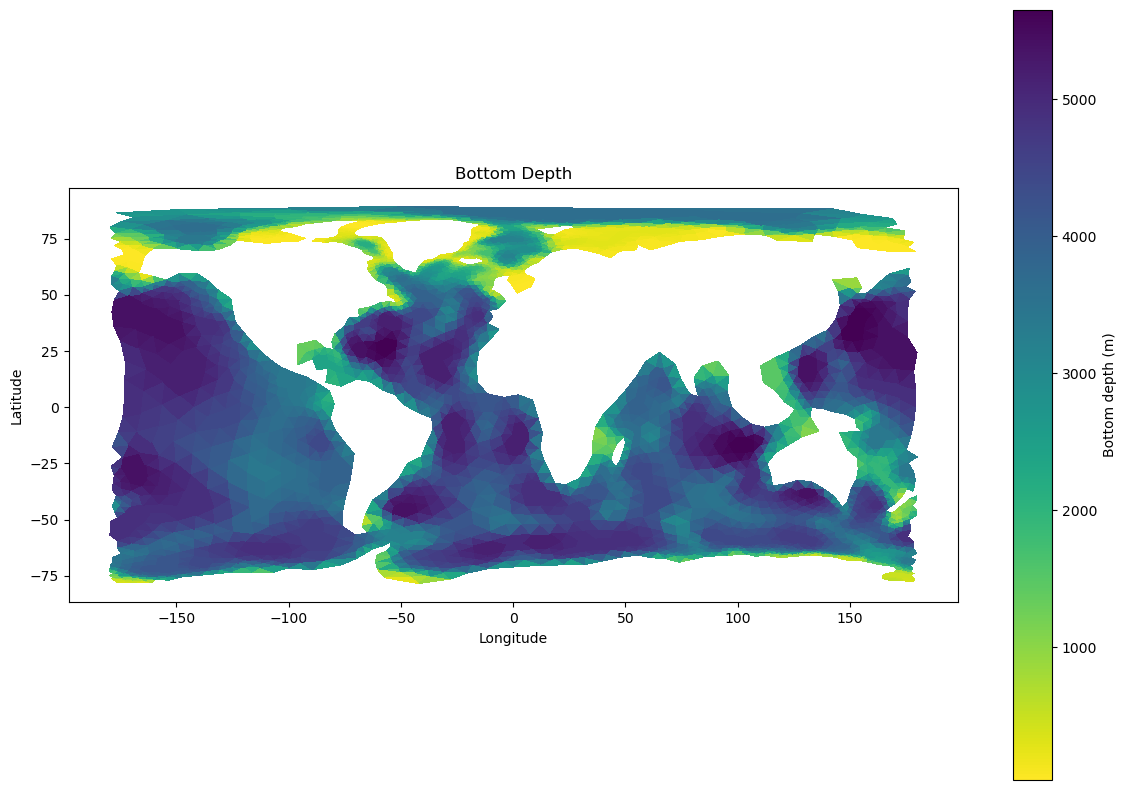

In [20]:
# Plot bottom depth on the mesh
# (triangulation already has mask applied from previous cell)
fig, ax = plt.subplots(figsize=(12, 8))

# Use tripcolor for filled triangles colored by node values
tcf = ax.tripcolor(triangulation, mesh.node_bottom_depth, 
                   shading='flat', cmap='viridis_r')
plt.colorbar(tcf, ax=ax, label='Bottom depth (m)')

ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_title('Bottom Depth')
ax.set_aspect('equal')
plt.tight_layout()
plt.show()

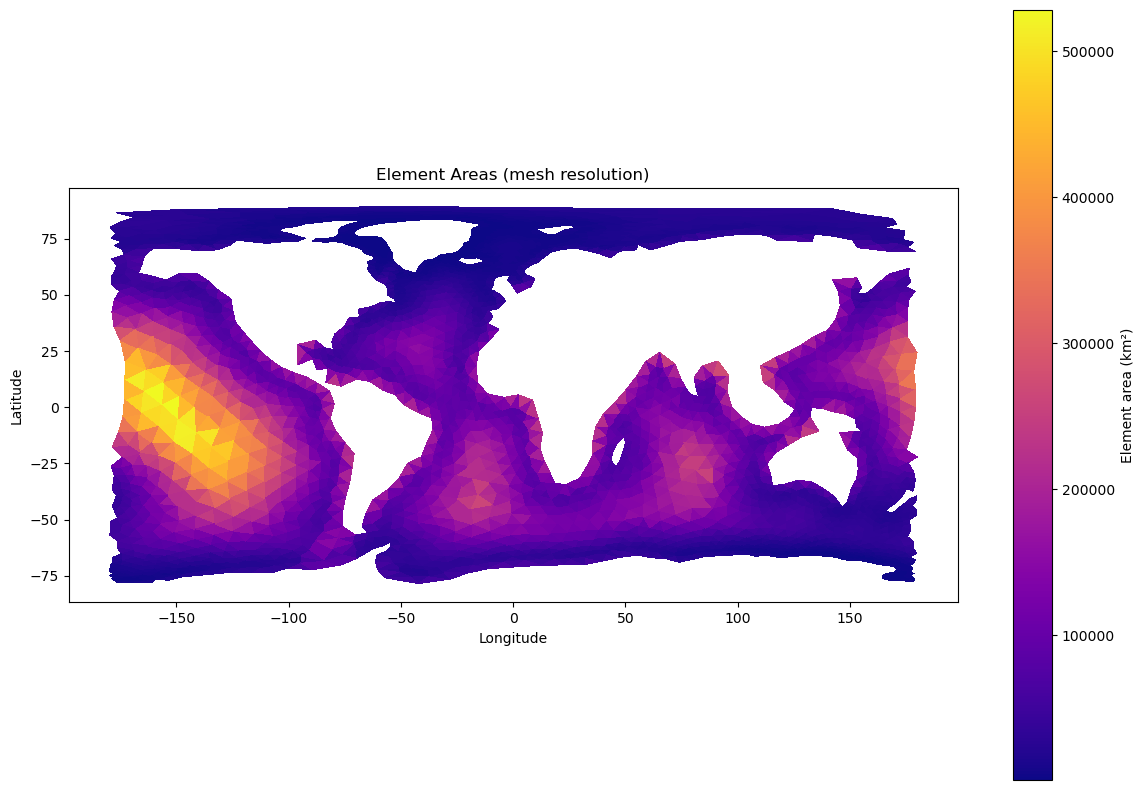

In [21]:
# Plot element areas
# For facecolors, we need to also mask the data for dateline-crossing triangles
fig, ax = plt.subplots(figsize=(12, 8))

area_km2 = mesh.geometry.elem_area / 1e6

# Get the mask from triangulation and apply to data
# Triangles crossing dateline should show as NaN
tri_lon = mesh.lon[mesh.triangles]
lon_range = tri_lon.max(axis=1) - tri_lon.min(axis=1)
cyclic_mask = lon_range > 180
area_km2_masked = np.where(cyclic_mask, np.nan, area_km2)

tcf = ax.tripcolor(triangulation, facecolors=area_km2_masked,
                   shading='flat', cmap='plasma')
plt.colorbar(tcf, ax=ax, label='Element area (km²)')

ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_title('Element Areas (mesh resolution)')
ax.set_aspect('equal')
plt.tight_layout()
plt.show()

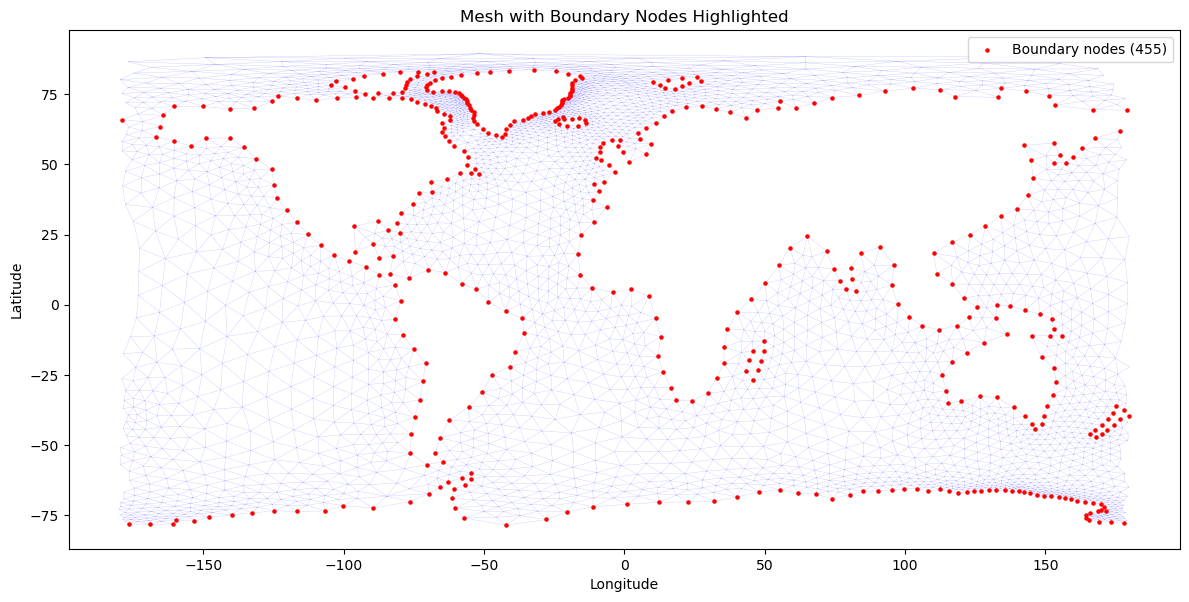

In [22]:
# Highlight boundary nodes
boundary_nodes = mesh.topology.get_boundary_nodes()

fig, ax = plt.subplots(figsize=(12, 8))
ax.triplot(triangulation, 'b-', linewidth=0.2, alpha=0.3)

# Plot boundary nodes in red
ax.scatter(mesh.lon[boundary_nodes], mesh.lat[boundary_nodes], 
           c='red', s=5, label=f'Boundary nodes ({len(boundary_nodes)})')

ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_title('Mesh with Boundary Nodes Highlighted')
ax.legend()
ax.set_aspect('equal')
plt.tight_layout()
plt.show()

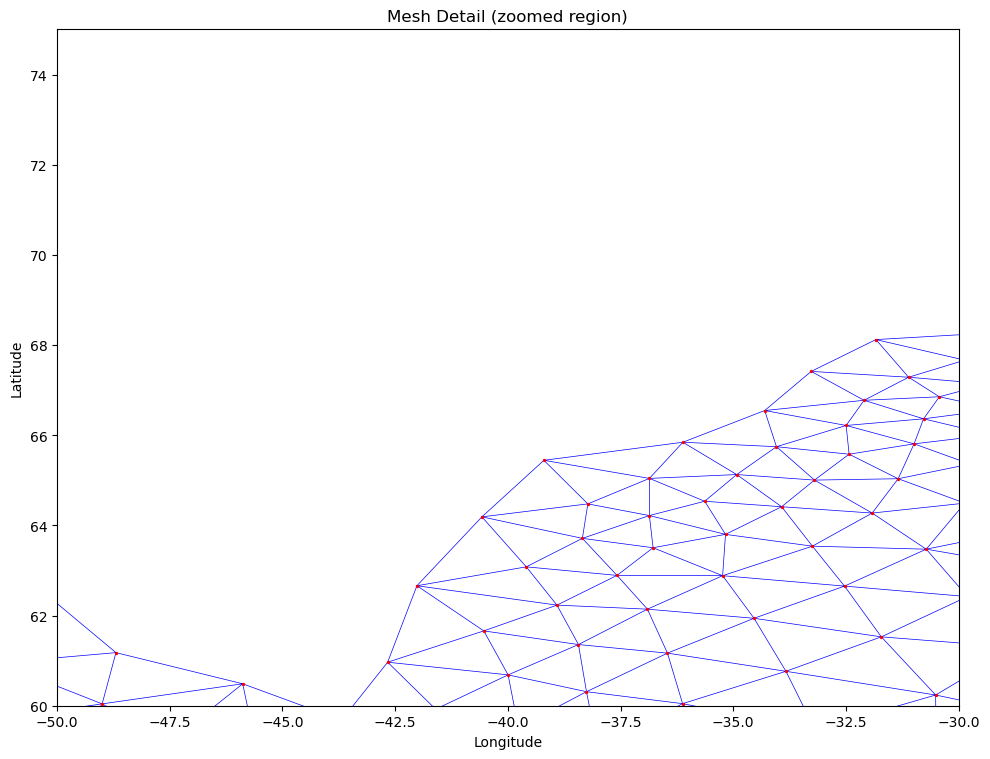

In [23]:
# Zoom into a region and show mesh detail
# When zooming to a region away from the dateline, the mask doesn't affect the view
fig, ax = plt.subplots(figsize=(10, 10))

ax.triplot(triangulation, 'b-', linewidth=0.5)
ax.scatter(mesh.lon, mesh.lat, c='red', s=2)

# Zoom to a region (North Atlantic - away from dateline)
ax.set_xlim(-50, -30)
ax.set_ylim(60, 75)

ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_title('Mesh Detail (zoomed region)')
ax.set_aspect('equal')
plt.tight_layout()
plt.show()

## 8. Working with Subsets

Examples of selecting and working with subsets of the mesh.

In [24]:
# Select nodes in a specific region
region_nodes = mesh.subset_by_bbox(lon_min=-60, lon_max=-30, 
                                    lat_min=50, lat_max=70)

print(f"Nodes in North Atlantic region: {len(region_nodes)}")

# Get properties for these nodes
region_depths = mesh.node_bottom_depth[region_nodes]
print(f"Depth range in region: {region_depths.min():.0f} to {region_depths.max():.0f} m")
print(f"Mean depth: {region_depths.mean():.0f} m")

Nodes in North Atlantic region: 157
Depth range in region: 115 to 3900 m
Mean depth: 1905 m


In [25]:
# Find elements where all vertices are in the region
# (i.e., elements completely contained in the bounding box)
region_nodes_set = set(region_nodes)

region_elements = []
for elem_idx, tri in enumerate(mesh.triangles):
    if all(node in region_nodes_set for node in tri):
        region_elements.append(elem_idx)

region_elements = np.array(region_elements)
print(f"Elements fully contained in region: {len(region_elements)}")

# Total area of the region
region_area_km2 = mesh.geometry.elem_area[region_elements].sum() / 1e6
print(f"Total area of region: {region_area_km2:.0f} km²")

Elements fully contained in region: 253
Total area of region: 2298516 km²


In [26]:
# Find deep vs shallow nodes
deep_threshold = 2000  # meters

deep_nodes = np.where(mesh.node_bottom_depth >= deep_threshold)[0]
shallow_nodes = np.where(mesh.node_bottom_depth < deep_threshold)[0]

print(f"Deep nodes (>{deep_threshold}m): {len(deep_nodes)} ({100*len(deep_nodes)/mesh.n2d:.1f}%)")
print(f"Shallow nodes (<{deep_threshold}m): {len(shallow_nodes)} ({100*len(shallow_nodes)/mesh.n2d:.1f}%)")

Deep nodes (>2000m): 2071 (66.0%)
Shallow nodes (<2000m): 1069 (34.0%)


## 9. Summary Statistics

In [27]:
# Compute mesh statistics
area_km2 = mesh.geometry.elem_area / 1e6

# Approximate element "resolution" as sqrt(area)
resolution_km = np.sqrt(area_km2)

print("=" * 50)
print("MESH SUMMARY")
print("=" * 50)
print(f"Nodes:                  {mesh.n2d:,}")
print(f"Elements:               {mesh.nelem:,}")
print(f"Edges:                  {mesh.topology.nedges:,}")
print(f"Vertical levels:        {mesh.nlev}")
print()
print(f"Longitude range:        {mesh.lon.min():.2f}° to {mesh.lon.max():.2f}°")
print(f"Latitude range:         {mesh.lat.min():.2f}° to {mesh.lat.max():.2f}°")
print()
print(f"Total mesh area:        {area_km2.sum():,.0f} km²")
print(f"Mean element area:      {area_km2.mean():,.0f} km²")
print(f"Resolution (approx):    {resolution_km.min():.1f} - {resolution_km.max():.1f} km")
print(f"Mean resolution:        {resolution_km.mean():.1f} km")
print()
print(f"Depth range:            {mesh.depth_levels.min():.0f} - {mesh.depth_levels.max():.0f} m")
print(f"Bottom depth range:     {mesh.node_bottom_depth.min():.0f} - {mesh.node_bottom_depth.max():.0f} m")
print(f"Boundary nodes:         {len(mesh.topology.get_boundary_nodes()):,}")
print("=" * 50)

MESH SUMMARY
Nodes:                  3,140
Elements:               5,839
Edges:                  8,986
Vertical levels:        48

Longitude range:        -179.96° to 179.96°
Latitude range:         -78.52° to 89.40°

Total mesh area:        339,720,479 km²
Mean element area:      58,181 km²
Resolution (approx):    25.7 - 726.9 km
Mean resolution:        199.6 km

Depth range:            -0 - 6250 m
Bottom depth range:     30 - 5650 m
Boundary nodes:         455
